In [30]:
import pandas as pd
import numpy as np


In [31]:
df = pd.read_csv('frame_metrics.csv')



In [32]:
df.columns

Index(['frame', 'timestamp', 'mean', 'local_entropy', 'temporal_entropy',
       'combined_entropy', 'edge_density', 'hist_entropy',
       'laplacian_variance'],
      dtype='str')

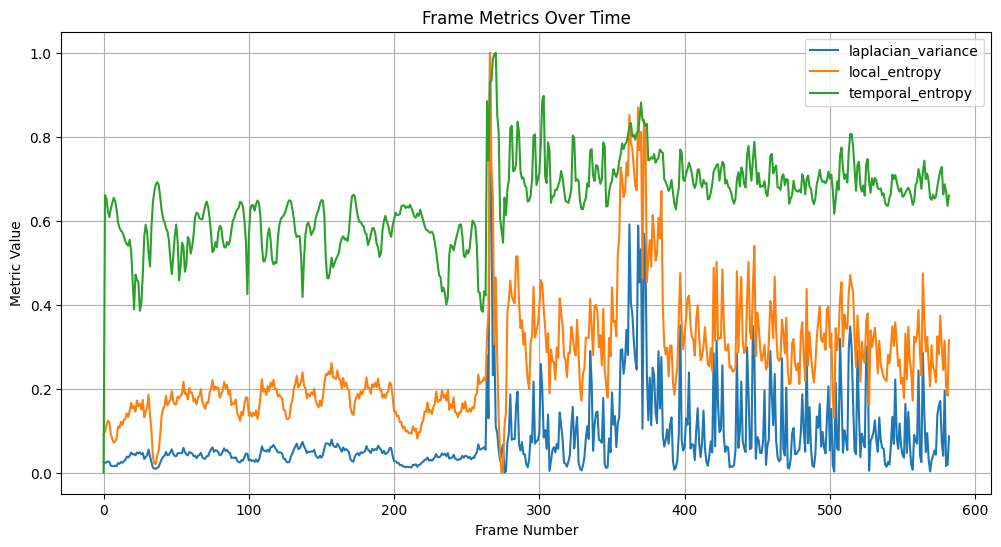

In [33]:
# display graphs of all metrics, x axis being the frame number, and y axis being the metric value, all in one graph, with a legend for each metric

do_not_display = {'frame', 'frame_no', 'timestamp', 'combined_entropy'}
all_metrics = set(df.columns) - set(do_not_display)
all_metrics = [
    # 'hist_entropy',
    'local_entropy',
    # 'edge_density',
    'temporal_entropy',
    'laplacian_variance'
]

all_metrics = sorted(all_metrics)  # Sort metrics alphabetically for consistent order in the legend
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

for metric in all_metrics:
    metric_values = df[metric]
    metric_values_normalized = (metric_values - np.min(metric_values)) / (np.max(metric_values) - np.min(metric_values))
    plt.plot(df['frame'], metric_values_normalized, label=metric) 

plt.xlabel('Frame Number')
plt.ylabel('Metric Value')
plt.title('Frame Metrics Over Time')
plt.legend()
plt.grid()
plt.show()


First sustained jump — Laplacian variance (sharpness) (jump ratio crossed above 1.5) at frame 254.0:


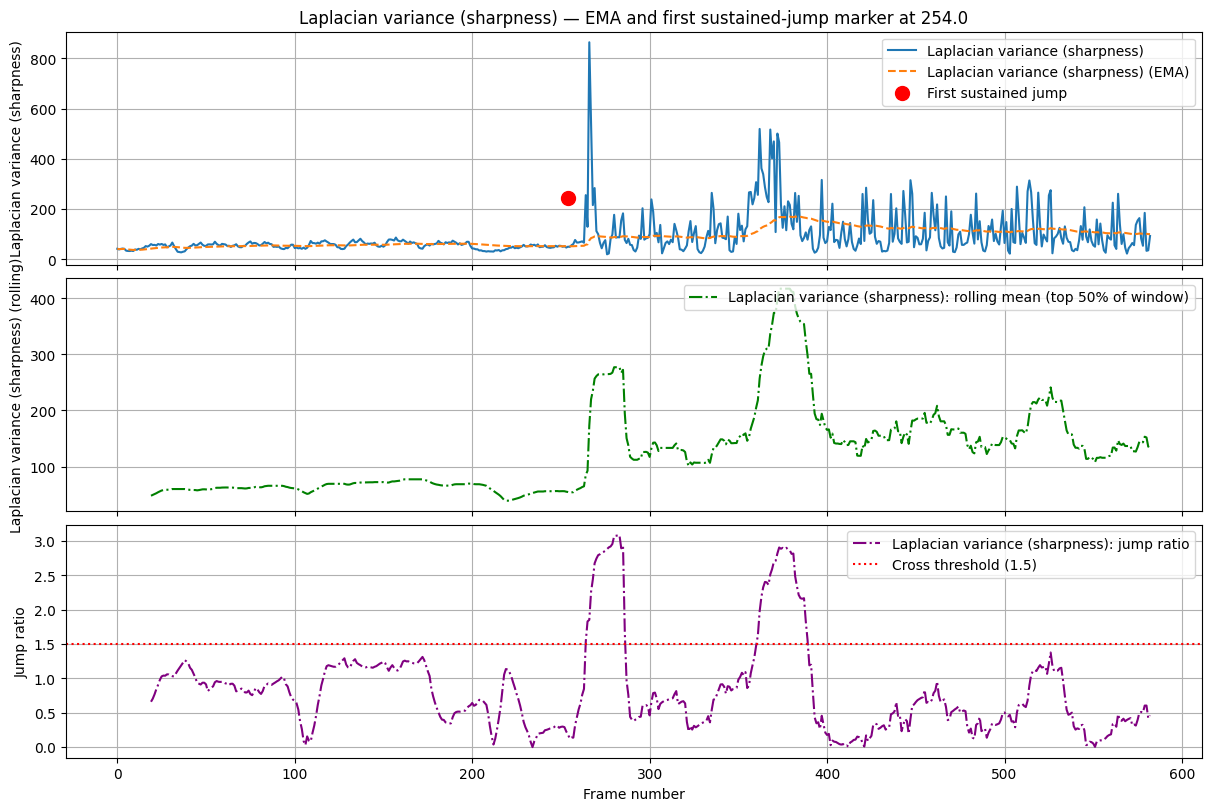

First sustained jump — Temporal entropy (jump ratio crossed above 1.5) at frame 257.0:


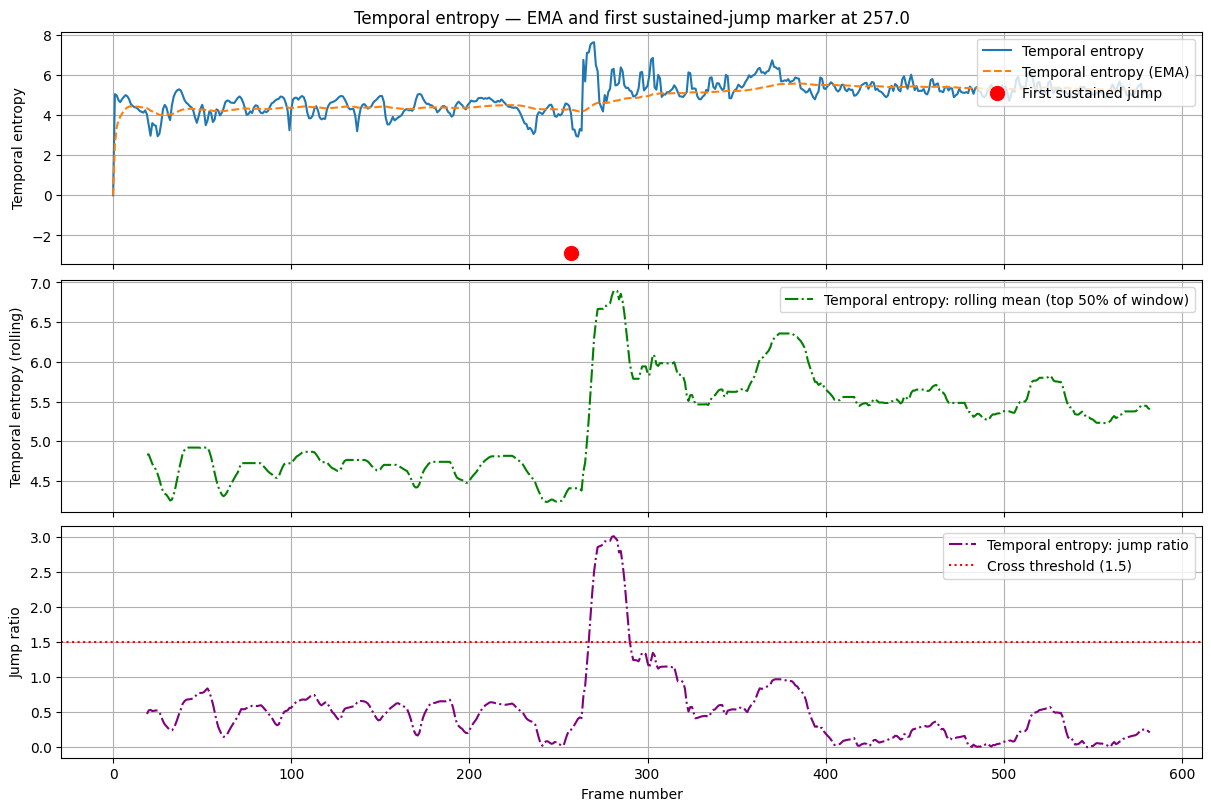

First sustained jump — Edge density (jump ratio crossed above 1.5) at frame 226.0:


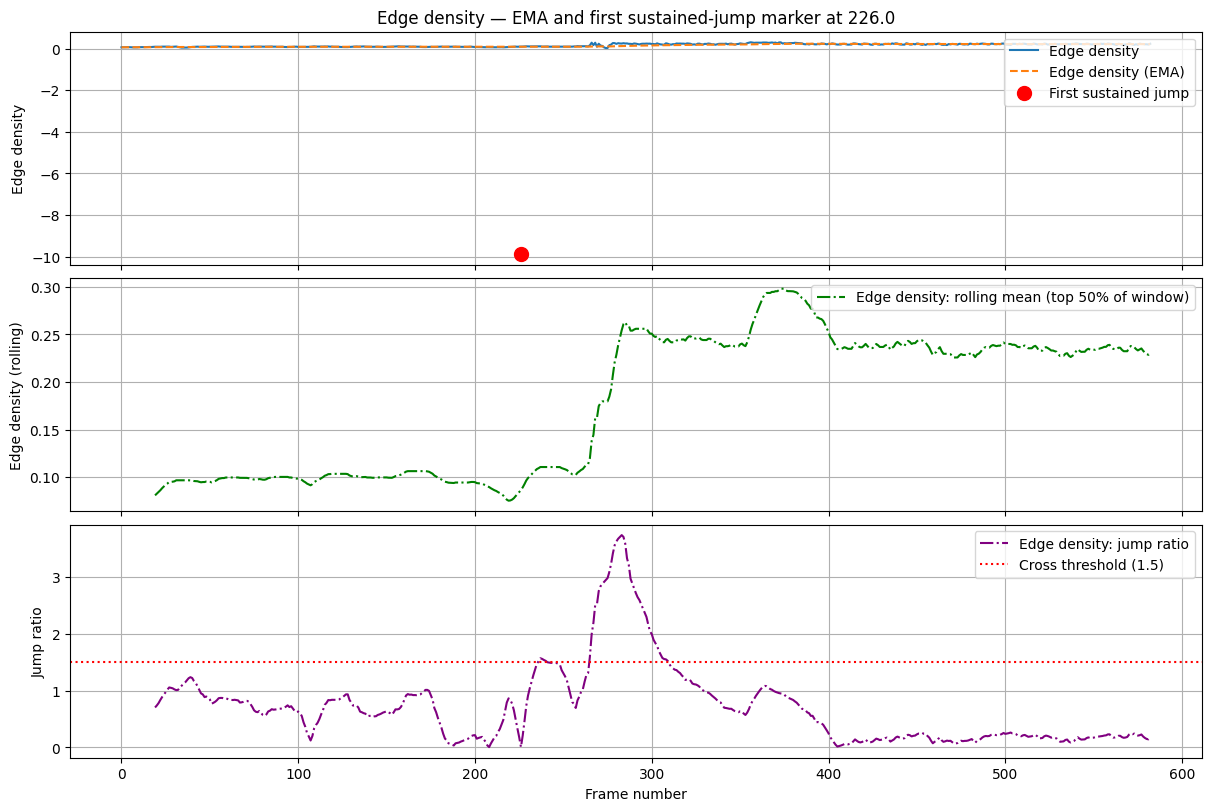

,frame,timestamp,mean,local_entropy,temporal_entropy,combined_entropy,edge_density,hist_entropy,laplacian_variance,laplacian_variance_ema,...,temporal_entropy_deviation,temporal_entropy_rolling_std,temporal_entropy_rolling_high,temporal_entropy_jump_ratio,edge_density_ema,edge_density_ema_std,edge_density_deviation,edge_density_rolling_std,edge_density_rolling_high,edge_density_jump_ratio
0,0,0.00,128.050237,1.959303,0.000000,1.371512,0.066740,6.935947,42.287722,42.287722,...,NaN,0.000000,NaN,NaN,0.066740,NaN,NaN,0.000000,NaN,NaN
1,1,0.02,126.102153,1.975311,5.041346,2.895122,0.068409,6.915795,39.725501,40.993801,...,0.700036,2.520673,NaN,NaN,0.067583,0.001180,0.700036,0.000834,NaN,NaN
2,2,0.04,125.929855,2.022337,4.978131,2.909076,0.073105,6.889626,41.961853,41.322960,...,0.557794,2.361755,NaN,NaN,0.069460,0.003310,1.101103,0.002694,NaN,NaN
3,3,0.06,124.522316,2.049231,4.744923,2.857939,0.075634,6.871339,43.206337,41.808022,...,0.417755,2.133915,NaN,NaN,0.071050,0.004117,1.113385,0.003562,NaN,NaN
4,4,0.08,124.448542,2.039446,4.642785,2.820448,0.074289,6.825838,41.980001,41.843808,...,0.338870,1.946224,NaN,NaN,0.071724,0.003840,0.667851,0.003451,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,578,11.56,24.648242,2.378141,5.055788,3.181435,0.223239,5.397002,54.422366,101.745452,...,-0.733490,0.758637,5.446775,0.252051,0.218948,0.021345,0.201068,0.072026,0.232802,0.192460
579,579,11.58,28.851918,2.568191,5.238765,3.369363,0.211888,5.557327,185.301668,103.400046,...,-0.061074,0.758102,5.446775,0.252668,0.218808,0.021156,-0.327103,0.071991,0.230833,0.167160
580,580,11.60,26.954210,2.276016,5.102514,3.123966,0.211554,5.316432,34.191687,102.029571,...,-0.558904,0.757488,5.446775,0.256865,0.218664,0.020970,-0.339067,0.071956,0.229403,0.149368
581,581,11.62,25.929053,2.210883,4.844871,3.001080,0.200385,5.272484,36.280503,100.727598,...,-1.472033,0.756843,5.419241,0.231362,0.218302,0.020918,-0.856530,0.071909,0.228572,0.142934


In [61]:
# Adaptive threshold detection using exponential moving average (decaying mean) with sustained jump detection via rolling mean of top-50% deviations
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('frame_metrics.csv')

import matplotlib.pyplot as plt

metrics = [
    'laplacian_variance',
    'temporal_entropy',
    'edge_density'
    ]

# Column name -> legend / human-readable label for plots and printouts
metric_legends = {
    "frame": "Frame index",
    "timestamp": "Timestamp (s)",
    "mean": "Mean pixel intensity",
    "local_entropy": "Local spatial entropy",
    "temporal_entropy": "Temporal entropy",
    "combined_entropy": "Combined entropy",
    "edge_density": "Edge density",
    "hist_entropy": "Histogram entropy",
    "laplacian_variance": "Laplacian variance (sharpness)",
}

# Compute exponential moving average (EMA) with a span (higher span = slower decay)
span = 100  # Adjust this for decay rate; larger span means more smoothing

# First sustained jump: first frame where jump ratio climbs above this (cross from at/below to above)
jump_ratio_cross_threshold = 1.5

# For sustained jumps: in each window, mean of the largest 50% of deviation values (by magnitude in the window)
def _rolling_mean_top_half(arr: np.ndarray) -> float:
    v = arr[~np.isnan(arr)]
    if v.size == 0:
        return np.nan
    k = max(1, int(np.ceil(0.5 * v.size)))
    return float(np.mean(np.partition(v, -k)[-k:]))

sustained_window =20
epsilon = 1e-5

for metric in metrics:
    leg = metric_legends.get(metric, metric)

    df[f'{metric}_ema'] = df[metric].ewm(span=span).mean()
    df[f'{metric}_ema_std'] = df[metric].ewm(span=span).std()
    df[f'{metric}_deviation'] = (df[metric] - df[f'{metric}_ema']) / df[f'{metric}_ema_std']
    df[f'{metric}_rolling_std'] = df[f'{metric}'].expanding().std(ddof=0)

    # df[f'{metric}_deviation_rolling'] = df[f'{metric}_deviation'].rolling(
    #     window=sustained_window, min_periods=sustained_window
    # ).apply(_rolling_mean_top_half, raw=True)

    df[f'{metric}_rolling_high'] = df[f'{metric}'].rolling(
        window=sustained_window, min_periods=sustained_window
    ).apply(_rolling_mean_top_half, raw=True)

    # df[f'{metric}_rolling_high'] = df[f'{metric}'].rolling(
    #     window=sustained_window, min_periods=sustained_window
    # ).apply(np.mean)


    # df[f'{metric}_jump_ratio'] = (epsilon + df[f'{metric}_rolling']) / (epsilon + df[f'{metric}_ema'])
    df[f'{metric}_jump_ratio'] = (
        (epsilon + np.abs(df[f'{metric}_rolling_high']  - df[f'{metric}_ema'] )) 
        / (epsilon + df[f'{metric}_rolling_std']))
       
    jr = df[f'{metric}_jump_ratio']

    prev_jr = jr.shift(1)
    crossed_above = (jr > jump_ratio_cross_threshold) & prev_jr.le(jump_ratio_cross_threshold).fillna(True)
    sustained_jumps = df[crossed_above] - sustained_window//2

    if not sustained_jumps.empty:
        first_sustained_jump = sustained_jumps.iloc[0]
        jump_frame = first_sustained_jump['frame']
        print(f"First sustained jump — {leg} (jump ratio crossed above {jump_ratio_cross_threshold}) at frame {first_sustained_jump['frame']}:")
        # print(first_sustained_jump[['frame', metric, f'{metric}_ema', f'{metric}_deviation', f'{metric}_deviation_rolling']])
    else:
        jump_frame = None
        print(f"No sustained jump — {leg} (jump ratio never crossed above {jump_ratio_cross_threshold}).")

    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8), layout="constrained")
    ax0, ax1, ax2 = axes

    ax0.plot(df["frame"], df[metric], label=leg)
    ax0.plot(df["frame"], df[f"{metric}_ema"], label=f"{leg} (EMA)", linestyle="--")
    if not sustained_jumps.empty:
        ax0.scatter(
            first_sustained_jump["frame"],
            first_sustained_jump[metric],
            color="red",
            label="First sustained jump",
            zorder=5,
            s=100,
        )
    ax0.set_ylabel(leg)
    ax0.set_title(f"{leg} — EMA and first sustained-jump marker at {jump_frame}")
    ax0.legend(loc="upper right")
    ax0.grid(True)

    ax1.plot(
        df["frame"],
        df[f"{metric}_rolling_high"],
        label=f"{leg}: rolling mean (top 50% of window)",
        color="green",
        linestyle="-.",
    )
    ax1.set_ylabel(f"{leg} (rolling)")
    ax1.legend(loc="upper right")
    ax1.grid(True)

    ax2.plot(
        df["frame"],
        df[f"{metric}_jump_ratio"],
        label=f"{leg}: jump ratio",
        color="purple",
        linestyle="-.",
    )
    ax2.axhline(y=jump_ratio_cross_threshold, color="red", linestyle=":", label=f"Cross threshold ({jump_ratio_cross_threshold})")
    ax2.set_xlabel("Frame number")
    ax2.set_ylabel("Jump ratio")
    ax2.legend(loc="upper right")
    ax2.grid(True)

    plt.show()

# # Suggestion: Sustained jump when the rolling mean of the top 50% of deviations in the window exceeds the threshold.

display(df)

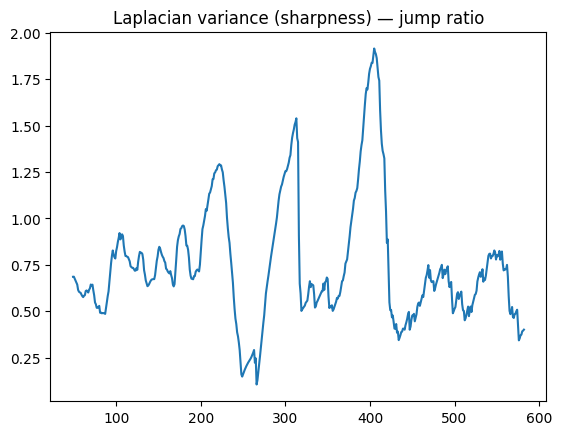

In [46]:
import matplotlib.pyplot as plt

for metric in metrics:
    leg = metric_legends.get(metric, metric)
    df[f"{metric}_jump_ratio"].plot(title=f"{leg} — jump ratio")
    plt.show()